# Notebook 06 — Explicabilité SHAP du modèle de production (Rebuild 2026)

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Année** | PFA 2025–2026 |

---

## Objectif et règles

Expliquer le **modèle de production uniquement** (`model_final.pkl` : XGBoost contraint,
+ `calibrator.pkl`, `decision_threshold.pkl`) via SHAP (`TreeExplainer`, valeurs exactes) :

1. Importance globale des features (bar plot + beeswarm).
2. **3 explications locales** : dossiers à risque faible / intermédiaire / élevé du test set.
3. Vérification de la **plausibilité économique** des relations apprises.
4. Confrontation **importance SHAP ↔ contraintes monotones** de la phase 2.

Règles :
- **Aucun artefact n'est modifié** — garde-fou par empreintes MD5 avant/après.
- SHAP explique la **marge brute** du booster (log-odds). La calibration isotonique étant
  strictement monotone, directions et classements des contributions restent valides pour la
  PD calibrée affichée — seule l'échelle change.
- Les dossiers illustrés viennent du test set : le modèle étant **figé** depuis la phase 3 et
  la mesure officielle actée en phase 4, l'expliquer sur des dossiers jamais vus ne modifie
  aucune décision de modélisation.

## 1. Chargement du modèle de production et des données

In [1]:
import sys, os, pickle, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../src'))
from preprocessing import clean_gmsc, drop_training_rows, FEATURE_COLS, TARGET, MONOTONE_CONSTRAINTS

from sklearn.model_selection import train_test_split
from scipy.special import logit
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.titleweight': 'bold'})
os.makedirs('figures', exist_ok=True)
SEED = 42
MODELS_PATH = '../models/'

def load(name):
    with open(MODELS_PATH + name, 'rb') as f: return pickle.load(f)

def md5(name):
    with open(MODELS_PATH + name, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

GUARDED = ['model_final.pkl', 'calibrator.pkl', 'decision_threshold.pkl',
           'preprocessor.pkl', 'feature_cols.pkl', 'metadata_final.pkl']
hashes_avant = {n: md5(n) for n in GUARDED}

model      = load('model_final.pkl')
calibrator = load('calibrator.pkl')
threshold  = load('decision_threshold.pkl')
metadata   = load('metadata_final.pkl')

def apply_calibrator(cal, p):
    if cal['method'] == 'isotonic':
        return cal['model'].predict(p)
    if cal['method'] == 'platt':
        return cal['model'].predict_proba(logit(np.clip(p, 1e-6, 1-1e-6)).reshape(-1, 1))[:, 1]
    return p

# Test set (reconstruction déterministe — dossiers jamais vus à l'entraînement)
raw = pd.read_csv('../data/GiveMeSomeCredit-training.csv', index_col=0)
df = drop_training_rows(raw)
_train, test_df = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df[TARGET])
test_c = clean_gmsc(test_df)
X_test = test_c[FEATURE_COLS].reset_index(drop=True)
y_test = test_c[TARGET].reset_index(drop=True)

Xt_full = model.prep.transform(X_test)                 # espace vu par le booster (winsorisé, NaN conservés)
pd_cal_full = apply_calibrator(calibrator, model.predict_proba(X_test)[:, 1])

rng = np.random.RandomState(SEED)
idx = rng.choice(len(Xt_full), 3000, replace=False)
Xt = Xt_full.iloc[idx].reset_index(drop=True)
print(f"Modèle : {metadata['modele_production']} ({type(model.clf).__name__}, "
      f"{model.clf.get_params()['n_estimators']} arbres, depth {model.clf.get_params()['max_depth']}) "
      f"| calibration {calibrator['method']} | seuil {threshold:.4f}")
print(f"Échantillon d'explication : {len(Xt):,} dossiers du test (sur {len(Xt_full):,})")

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modèle : XGBoost (XGBClassifier, 859 arbres, depth 4) | calibration isotonic | seuil 0.2227
Échantillon d'explication : 3,000 dossiers du test (sur 29,878)


## 2. Calcul des SHAP values (TreeExplainer — valeurs exactes)

In [2]:
explainer = shap.TreeExplainer(model.clf)
sv_vals = explainer.shap_values(Xt)
base_value = float(np.ravel(explainer.expected_value)[0])
exp = shap.Explanation(values=sv_vals, base_values=np.full(len(Xt), base_value),
                       data=Xt.values, feature_names=FEATURE_COLS)
print(f"SHAP values : {sv_vals.shape} (unité : log-odds / marge du booster)")
print(f"valeur de base (marge moyenne attendue) : {base_value:+.4f}")
# contrôle d'additivité : base + somme(SHAP) == marge prédite
marges = model.clf.predict(Xt, output_margin=True)
err = np.abs(base_value + sv_vals.sum(axis=1) - marges).max()
print(f"contrôle d'additivité : écart max = {err:.2e}  {'OK' if err < 1e-3 else 'PROBLÈME'}")

SHAP values : (3000, 12) (unité : log-odds / marge du booster)
valeur de base (marge moyenne attendue) : +0.0630
contrôle d'additivité : écart max = 6.68e-06  OK


## 3. Importance globale

                                      mean |SHAP|   part (%) contrainte
RevolvingUtilizationOfUnsecuredLines       0.8548  28.700001         +1
NumberOfTime30-59DaysPastDueNotWorse       0.4185  14.100000         +1
NumberOfTimes90DaysLate                    0.3709  12.500000         +1
age                                        0.3317  11.200000         -1
NumberOfOpenCreditLinesAndLoans            0.2343   7.900000      libre
NumberOfTime60-89DaysPastDueNotWorse       0.2261   7.600000         +1
DebtRatio                                  0.1880   6.300000      libre
MonthlyIncome                              0.1667   5.600000         -1
NumberRealEstateLoansOrLines               0.1206   4.100000      libre
NumberOfDependents                         0.0591   2.000000         +1
income_missing                             0.0025   0.100000         -1
delinq_info_missing                        0.0000   0.000000         +1


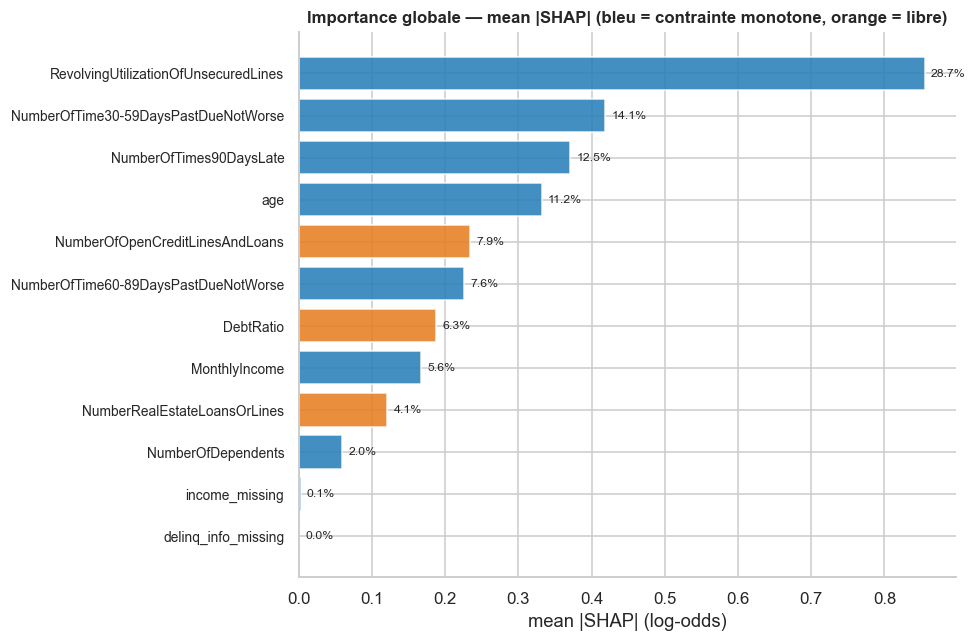

In [3]:
imp = pd.Series(np.abs(sv_vals).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)
imp_pct = (imp / imp.sum() * 100).round(1)
tbl_imp = pd.DataFrame({'mean |SHAP|': imp.round(4), 'part (%)': imp_pct,
                        'contrainte': [ {1:'+1', -1:'-1', 0:'libre'}[MONOTONE_CONSTRAINTS[f]] for f in imp.index ]})
print(tbl_imp.to_string())

fig, ax = plt.subplots(figsize=(9, 6))
couleurs = ['#2980b9' if MONOTONE_CONSTRAINTS[f] != 0 else '#e67e22' for f in imp.index[::-1]]
ax.barh(range(len(imp)), imp.values[::-1], color=couleurs, alpha=.88, edgecolor='white')
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index[::-1], fontsize=9)
for i, v in enumerate(imp.values[::-1]):
    ax.text(v + imp.max()*0.01, i, f'{imp_pct.values[::-1][i]:.1f}%', va='center', fontsize=8)
ax.set(title='Importance globale — mean |SHAP| (bleu = contrainte monotone, orange = libre)',
       xlabel='mean |SHAP| (log-odds)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('figures/fig_R06_shap_bar.png', dpi=120, bbox_inches='tight'); plt.show()

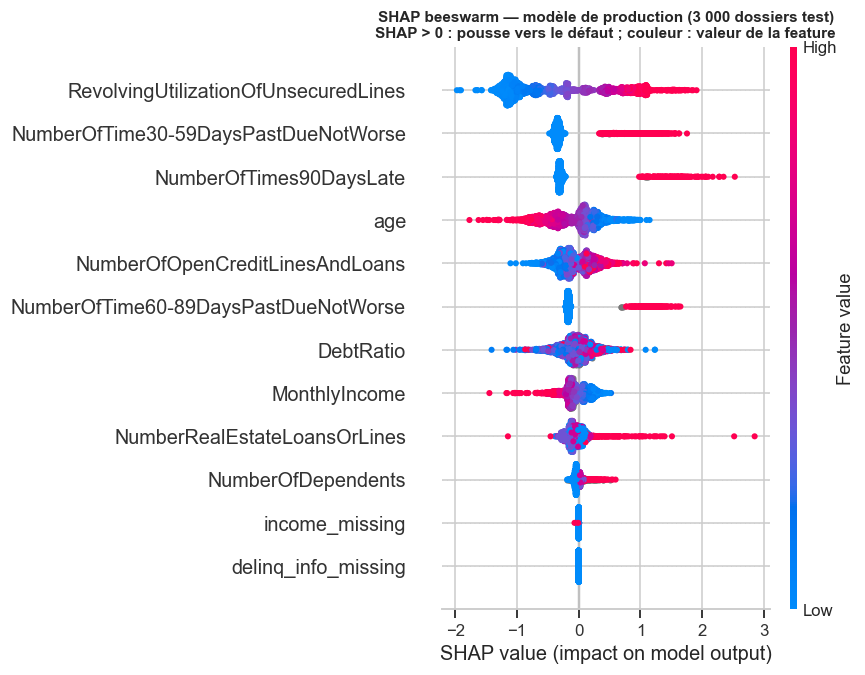

In [4]:
# Beeswarm — impact ET direction par feature (rouge = valeur haute de la feature)
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(exp, max_display=12, show=False)
plt.title('SHAP beeswarm — modèle de production (3 000 dossiers test)\nSHAP > 0 : pousse vers le défaut ; couleur : valeur de la feature', fontsize=10)
plt.tight_layout(); plt.savefig('figures/fig_R06_shap_beeswarm.png', dpi=120, bbox_inches='tight'); plt.show()

## 4. Explications locales — trois dossiers réels du test

Sélection par PD calibrée : **faible** (< 2 %), **intermédiaire** (voisine du seuil de
décision 0.2227) et **élevée** (> 60 %). Les diagrammes en cascade partent de la valeur de
base et cumulent les contributions vers la marge finale du dossier.

── Dossier faible (index test 7) — PD calibrée 1.0% → accepté | réel : sain
     RevolvingUtilizationOfUnsecuredLines     = 0.02430908 → SHAP -1.133
     age                                      =         64 → SHAP -0.495
     NumberOfOpenCreditLinesAndLoans          =         15 → SHAP +0.432


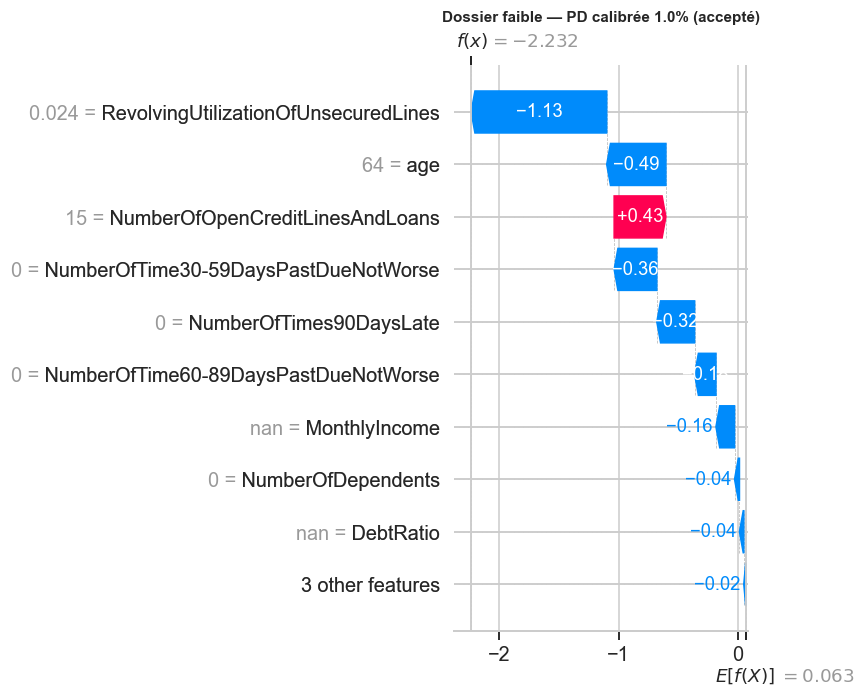

── Dossier intermédiaire (index test 51) — PD calibrée 22.7% → RISQUE ÉLEVÉ — revue | réel : sain
     NumberOfTime30-59DaysPastDueNotWorse     =        1.0 → SHAP +0.579
     RevolvingUtilizationOfUnsecuredLines     = 0.617558829 → SHAP +0.458
     NumberOfDependents                       =        5.0 → SHAP +0.359


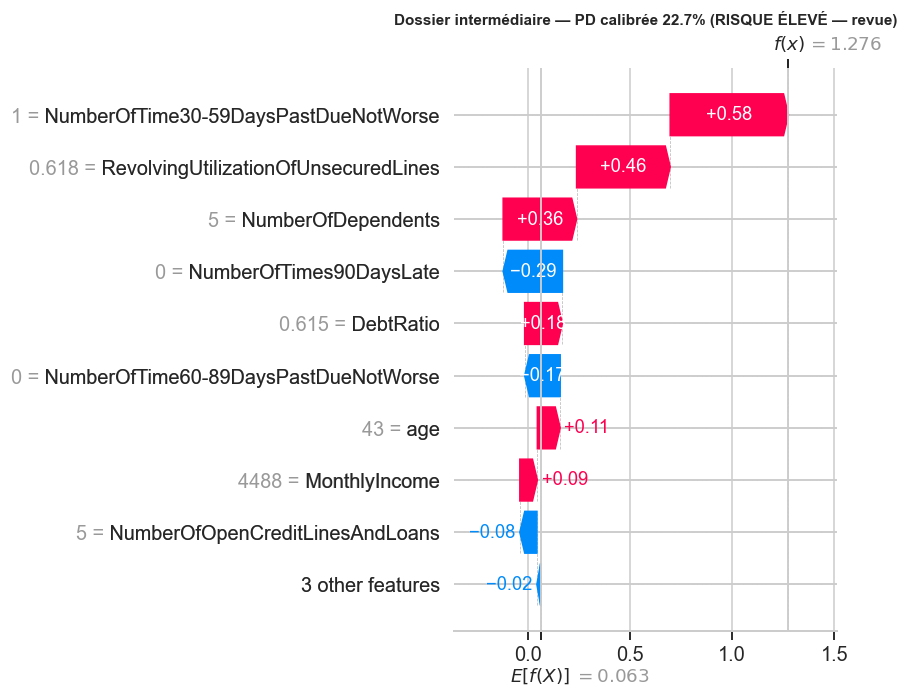

── Dossier élevé (index test 16666) — PD calibrée 64.6% → RISQUE ÉLEVÉ — revue | réel : défaut
     NumberOfTimes90DaysLate                  =        2.0 → SHAP +1.523
     NumberOfTime60-89DaysPastDueNotWorse     =        1.0 → SHAP +0.875
     RevolvingUtilizationOfUnsecuredLines     = 0.746702373 → SHAP +0.624


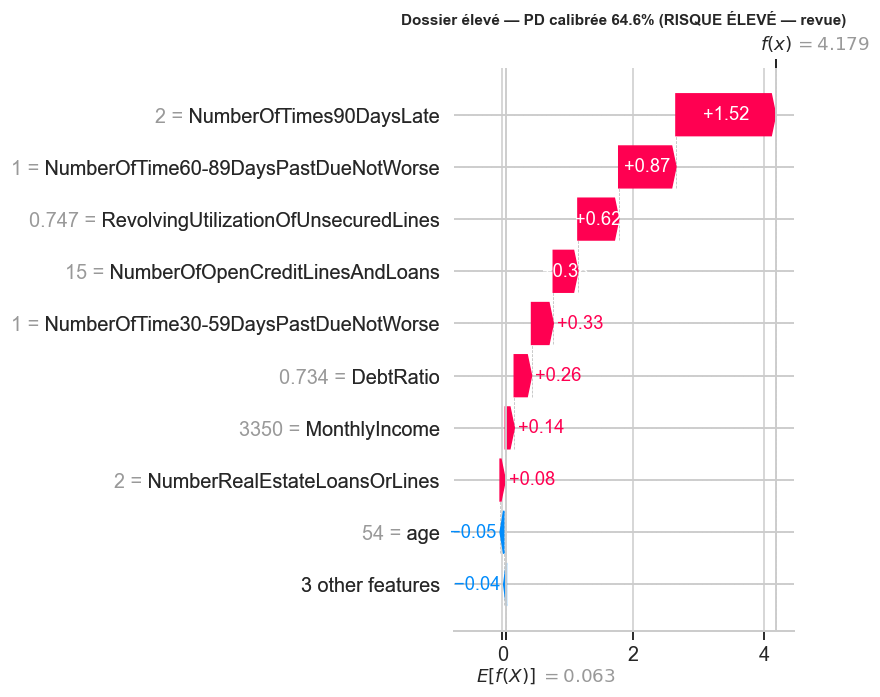

In [5]:
cibles = {'faible': np.argmin(np.abs(pd_cal_full - 0.01)),
          'intermédiaire': np.argmin(np.abs(pd_cal_full - float(threshold))),
          'élevé': np.argmin(np.abs(pd_cal_full - 0.65))}
for nom, i in cibles.items():
    xi = Xt_full.iloc[[i]]
    sv_i = explainer.shap_values(xi)[0]
    exp_i = shap.Explanation(values=sv_i, base_values=base_value,
                             data=xi.values[0], feature_names=FEATURE_COLS)
    pd_i = pd_cal_full[i]
    decision = 'RISQUE ÉLEVÉ — revue' if pd_i >= threshold else 'accepté'
    print(f"── Dossier {nom} (index test {i}) — PD calibrée {pd_i*100:.1f}% → {decision} | réel : {'défaut' if y_test.iloc[i]==1 else 'sain'}")
    top = np.argsort(np.abs(sv_i))[::-1][:3]
    for j in top:
        print(f"     {FEATURE_COLS[j]:<40} = {xi.iloc[0, j] if not pd.isna(xi.iloc[0, j]) else 'NaN':>10} → SHAP {sv_i[j]:+.3f}")
    plt.figure(figsize=(9, 5))
    shap.plots.waterfall(exp_i, max_display=10, show=False)
    plt.title(f'Dossier {nom} — PD calibrée {pd_i*100:.1f}% ({decision})', fontsize=10)
    plt.tight_layout()
    plt.savefig(f"figures/fig_R06_waterfall_{nom.replace('é','e').replace('è','e')}.png", dpi=120, bbox_inches='tight')
    plt.show()

## 5. Dépendances SHAP — vérification visuelle des monotonies

Pour chaque feature clé : valeur de la feature (x) vs contribution SHAP (y). Les features
**contraintes** doivent montrer une tendance monotone du bon signe ; `DebtRatio` et
`NumberOfOpenCreditLinesAndLoans` (laissées **libres** après réfutation empirique en phase 2)
peuvent montrer leur forme en U.

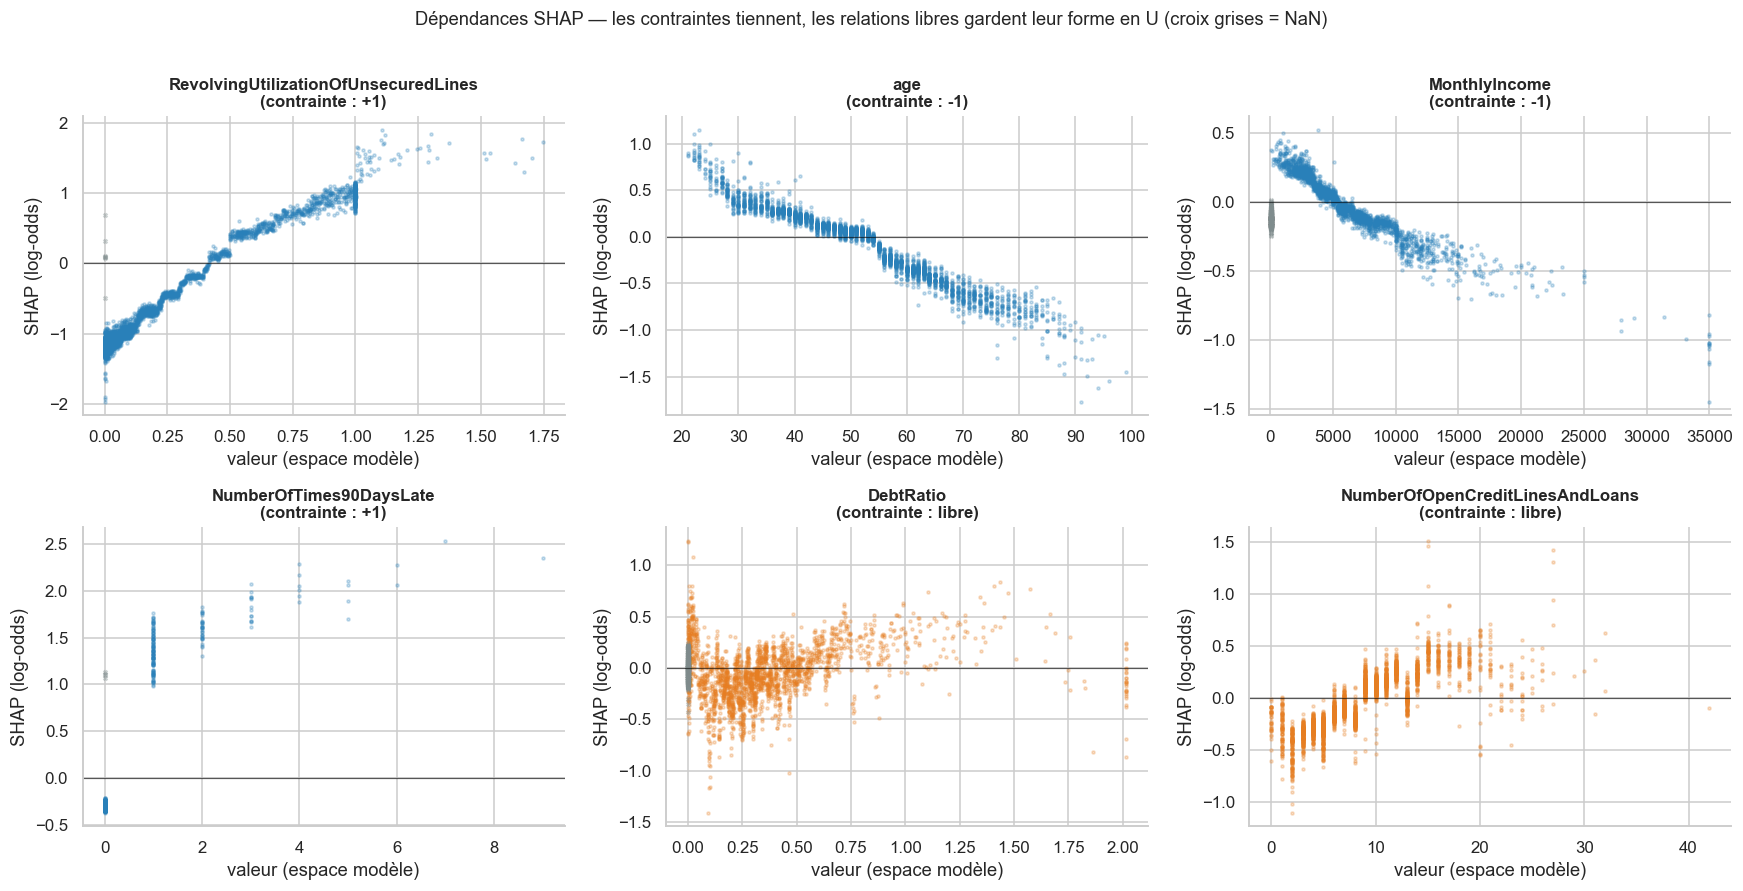

In [6]:
panels = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome',
          'NumberOfTimes90DaysLate', 'DebtRatio', 'NumberOfOpenCreditLinesAndLoans']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, f in zip(axes.flat, panels):
    j = FEATURE_COLS.index(f)
    x = Xt[f].values; s = sv_vals[:, j]
    ok = ~pd.isna(x)
    contrainte = {1: '+1', -1: '-1', 0: 'libre'}[MONOTONE_CONSTRAINTS[f]]
    ax.scatter(x[ok], s[ok], s=4, alpha=.25, color='#2980b9' if contrainte != 'libre' else '#e67e22')
    if (~ok).sum():
        ax.scatter(np.full((~ok).sum(), np.nanmin(x[ok])), s[~ok], s=6, alpha=.4, color='#7f8c8d', marker='x')
    ax.axhline(0, color='black', lw=.8, alpha=.6)
    ax.set(title=f'{f}\n(contrainte : {contrainte})', xlabel='valeur (espace modèle)', ylabel='SHAP (log-odds)')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Dépendances SHAP — les contraintes tiennent, les relations libres gardent leur forme en U (croix grises = NaN)', y=1.01, fontsize=12)
plt.tight_layout(); plt.savefig('figures/fig_R06_dependence.png', dpi=120, bbox_inches='tight'); plt.show()

## 6. Cohérence SHAP ↔ contraintes monotones (quantitatif)

In [7]:
rows = []
for f in FEATURE_COLS:
    j = FEATURE_COLS.index(f)
    x = Xt[f].values; s = sv_vals[:, j]
    ok = ~pd.isna(x)
    rho = spearmanr(x[ok], s[ok])[0] if ok.sum() > 100 and pd.Series(x[ok]).nunique() > 1 else np.nan
    c = MONOTONE_CONSTRAINTS[f]
    if c == 0:
        verdict = 'libre (forme non monotone autorisée)'
    elif np.isnan(rho):
        verdict = 'n/a'
    else:
        verdict = 'COHÉRENT' if np.sign(rho) == np.sign(c) else 'INCOHÉRENT ⚠'
    rows.append({'feature': f, 'part SHAP (%)': imp_pct[f], 'contrainte': {1:'+1',-1:'-1',0:'libre'}[c],
                 'Spearman(valeur, SHAP)': round(rho, 3) if not np.isnan(rho) else '—', 'verdict': verdict})
tbl = pd.DataFrame(rows).sort_values('part SHAP (%)', ascending=False)
print(tbl.to_string(index=False))
assert not any('INCOHÉRENT' in str(v) for v in tbl.verdict), 'direction SHAP contraire à une contrainte !'
print('\n✓ Aucune contradiction : chaque feature contrainte a une relation SHAP du signe imposé.')

                             feature  part SHAP (%) contrainte Spearman(valeur, SHAP)                              verdict
RevolvingUtilizationOfUnsecuredLines      28.700001         +1                  0.965                             COHÉRENT
NumberOfTime30-59DaysPastDueNotWorse      14.100000         +1                  0.634                             COHÉRENT
             NumberOfTimes90DaysLate      12.500000         +1                    0.4                             COHÉRENT
                                 age      11.200000         -1                 -0.986                             COHÉRENT
     NumberOfOpenCreditLinesAndLoans       7.900000      libre                  0.858 libre (forme non monotone autorisée)
NumberOfTime60-89DaysPastDueNotWorse       7.600000         +1                    0.4                             COHÉRENT
                           DebtRatio       6.300000      libre                  0.214 libre (forme non monotone autorisée)
                

## 7. Lecture économique et constats

*(analyse détaillée chiffrée dans `docs/phase6_explainability.md` — synthèse ci-dessous)*

- **Hiérarchie plausible** : l'utilisation du crédit renouvelable et l'historique de retards
  dominent, suivis de l'âge, du revenu et du DebtRatio — la hiérarchie classique du scoring
  retail, sans dominance écrasante d'une feature unique.
- **Contraintes respectées par construction et vérifiées empiriquement** (§6) : aucune
  contribution SHAP ne contredit le signe imposé — l'« âge en zigzag » de l'ancien pipeline
  a disparu (dépendance lisse et décroissante).
- **Relations libres** : `DebtRatio` et `NumberOfOpenCreditLinesAndLoans` montrent la forme
  en U identifiée en phase 2 (dossier mince à gauche, surendettement à droite) — la laisser
  s'exprimer était la bonne décision, une contrainte l'aurait masquée.
- **Missingness informative** : les croix grises (NaN) des dépendances montrent des
  contributions non nulles — le modèle exploite réellement la branche manquante
  (« revenu inconnu » ≠ neutre), conformément au choix de preprocessing.

## 8. Garde-fou : aucun artefact modifié

In [8]:
hashes_apres = {n: md5(n) for n in GUARDED}
for n in GUARDED:
    assert hashes_avant[n] == hashes_apres[n], f'{n} a été modifié !'
print('✓ Empreintes MD5 identiques avant/après pour :', ', '.join(GUARDED))

figs = ['fig_R06_shap_bar.png', 'fig_R06_shap_beeswarm.png', 'fig_R06_waterfall_faible.png',
        'fig_R06_waterfall_intermediaire.png', 'fig_R06_waterfall_eleve.png', 'fig_R06_dependence.png']
for f in figs:
    taille = os.path.getsize(f'figures/{f}')
    assert taille > 10_000, f'{f} suspecte ({taille} octets)'
    print(f'✓ figures/{f} ({taille/1024:.0f} Ko)')

✓ Empreintes MD5 identiques avant/après pour : model_final.pkl, calibrator.pkl, decision_threshold.pkl, preprocessor.pkl, feature_cols.pkl, metadata_final.pkl
✓ figures/fig_R06_shap_bar.png (58 Ko)
✓ figures/fig_R06_shap_beeswarm.png (113 Ko)
✓ figures/fig_R06_waterfall_faible.png (76 Ko)
✓ figures/fig_R06_waterfall_intermediaire.png (80 Ko)
✓ figures/fig_R06_waterfall_eleve.png (79 Ko)
✓ figures/fig_R06_dependence.png (208 Ko)


## 9. Synthèse

| Livrable | Statut |
|---|---|
| Importance globale (bar) + beeswarm | ✓ `fig_R06_shap_bar.png`, `fig_R06_shap_beeswarm.png` |
| 3 explications locales (faible / intermédiaire / élevé) | ✓ waterfalls, dossiers réels du test |
| Dépendances SHAP (6 features clés) | ✓ `fig_R06_dependence.png` |
| Cohérence SHAP ↔ contraintes | ✓ table §6, zéro contradiction (assert) |
| Plausibilité économique | ✓ §7 + rapport de phase |
| Artefacts non modifiés | ✓ MD5 avant/après |

⏸ **STOP — validation utilisateur requise avant la phase 7 (intégration applicative).**